In [4]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

# Определение корня проекта
project_root = Path.cwd()
while not (project_root / "data").exists() and project_root != project_root.parent:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Импортируем 2D-генератор
from src.synthetic.cvae_2d_synthesis import ImageConditionalVAE

# =====================================================================
# ⚙️ ПАРАМЕТРЫ ЭКСПЕРИМЕНТА
# =====================================================================
PROCESSED_DATA_DIR = project_root / "data" / "processed" / "images" / "train"
SYNTHETIC_DATA_DIR = project_root / "data" / "synthetic" / "2d_frames"

BATCH_SIZE = 64
EPOCHS = 100
LEARNING_RATE = 1e-3
LOSS_BETA = 0.5  # Баланс между качеством картинки и разнообразием

TARGETS_TO_GENERATE = [0.3, 0.5, 0.7] # % воды для синтетики
SAMPLES_PER_TARGET = 10               # Сколько кадров сгенерировать

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {DEVICE}")

Устройство: cpu


In [5]:
print("Сборка 2D датасета из покадровых файлов...")

# Координаты зон (ожидаемый размер патча ~86x86 пикселей)
zones_info = {
    'epoxy':     ([210, 70, 295, 155], 1.2),
    'water_100': ([300, 70, 385, 155], 1.0),
    'water_80':  ([390, 70, 475, 155], 0.8),
    'water_60':  ([207, 220, 292, 305], 0.6),
    'water_40':  ([300, 220, 385, 305], 0.4),
    'water_20':  ([393, 220, 478, 305], 0.2)
}

if not PROCESSED_DATA_DIR.exists():
    raise FileNotFoundError(f"Папка {PROCESSED_DATA_DIR} не найдена!")

all_files = list(PROCESSED_DATA_DIR.glob("*.npy"))
# Ищем уникальные префиксы образцов (water1, water2, water4)
prefixes = sorted(list(set([f.name.split('_frame_')[0] for f in all_files])))

X_frames, y_labels = [], []

for prefix in prefixes:
    print(f"Обработка образца: {prefix}")
    frame_files = sorted(PROCESSED_DATA_DIR.glob(f"{prefix}_frame_*.npy"))
    
    if not frame_files:
        continue
        
    # Фоновый (нулевой) кадр для вычитания
    bg_frame = np.load(frame_files[0])
    
    # Чтобы не переполнить RAM, берем каждый 10-й кадр (фаза активного остывания)
    # Вы можете изменить шаг (step), если памяти достаточно
    for fpath in tqdm(frame_files[100::10], desc=f"Чтение кадров {prefix}"):
        current_frame = np.load(fpath)
        delta_frame = current_frame - bg_frame # Вычитаем фон
        
        for label, (bbox, target) in zones_info.items():
            x1, y1, x2, y2 = bbox
            patch = delta_frame[y1:y2+1, x1:x2+1]
            
            # Приводим к размеру 86x86 (добавляем паддинг, если нужно)
            if patch.shape == (86, 86):
                X_frames.append(patch)
                y_labels.append([target])

# Конвертация в тензоры PyTorch: (Batch, Channels, Height, Width) -> (N, 1, 86, 86)
X_tensor = torch.FloatTensor(np.array(X_frames)).unsqueeze(1)
y_tensor = torch.FloatTensor(np.array(y_labels))

print(f"✅ Датасет собран! Форма X: {X_tensor.shape}, Форма y: {y_tensor.shape}")

dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

Сборка 2D датасета из покадровых файлов...
Обработка образца: water1



Чтение кадров water1: 100%|██████████████████████████████████████████████████████████| 290/290 [00:04<00:00, 63.83it/s]


Обработка образца: water2



Чтение кадров water2: 100%|██████████████████████████████████████████████████████████| 290/290 [00:04<00:00, 68.55it/s]


Обработка образца: water4



Чтение кадров water4: 100%|██████████████████████████████████████████████████████████| 290/290 [00:04<00:00, 70.62it/s]


✅ Датасет собран! Форма X: torch.Size([5220, 1, 86, 86]), Форма y: torch.Size([5220, 1])


Начало обучения CNN CVAE...
Эпоха [10/100] | Total Loss: 613.95
Эпоха [20/100] | Total Loss: 342.35
Эпоха [30/100] | Total Loss: 220.53
Эпоха [40/100] | Total Loss: 197.17
Эпоха [50/100] | Total Loss: 177.22
Эпоха [60/100] | Total Loss: 156.94
Эпоха [70/100] | Total Loss: 157.38
Эпоха [80/100] | Total Loss: 152.58
Эпоха [90/100] | Total Loss: 244.66
Эпоха [100/100] | Total Loss: 138.89


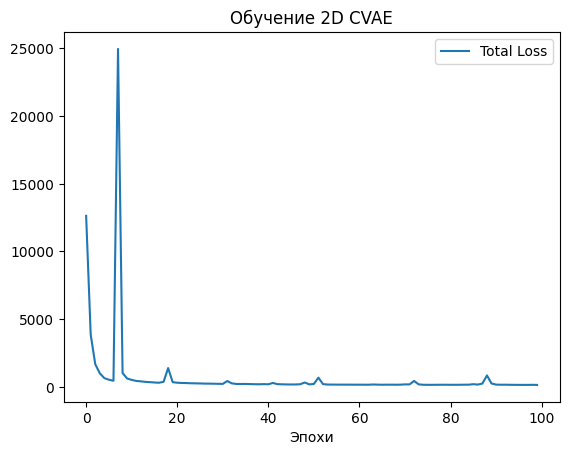

In [6]:
# Функция потерь для VAE
def cvae_loss_fn(x_hat, x, mu, logvar, beta=1.0):
    # MSE loss для картинок
    recon_loss = F.mse_loss(x_hat, x, reduction='sum') / x.size(0)
    # KL Divergence для скрытого пространства
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon_loss + beta * kld_loss, recon_loss, kld_loss

model = ImageConditionalVAE(cond_dim=1, latent_dim=64).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("Начало обучения CNN CVAE...")
history = {'loss': [], 'recon': []}

for epoch in range(EPOCHS):
    model.train()
    total_loss, total_recon = 0, 0
    
    for batch_x, batch_y in dataloader:
        batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
        
        optimizer.zero_grad()
        x_hat, mu, logvar = model(batch_x, batch_y)
        
        loss, recon, kl = cvae_loss_fn(x_hat, batch_x, mu, logvar, beta=LOSS_BETA)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_recon += recon.item()
        
    avg_loss = total_loss / len(dataloader)
    history['loss'].append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Эпоха [{epoch+1}/{EPOCHS}] | Total Loss: {avg_loss:.2f}")

plt.plot(history['loss'], label='Total Loss')
plt.title('Обучение 2D CVAE')
plt.xlabel('Эпохи')
plt.legend()
plt.show()

Экспорт синтетики в: C:\programming\studcamp\project\honeycomb-water-detection\data\synthetic\2d_frames


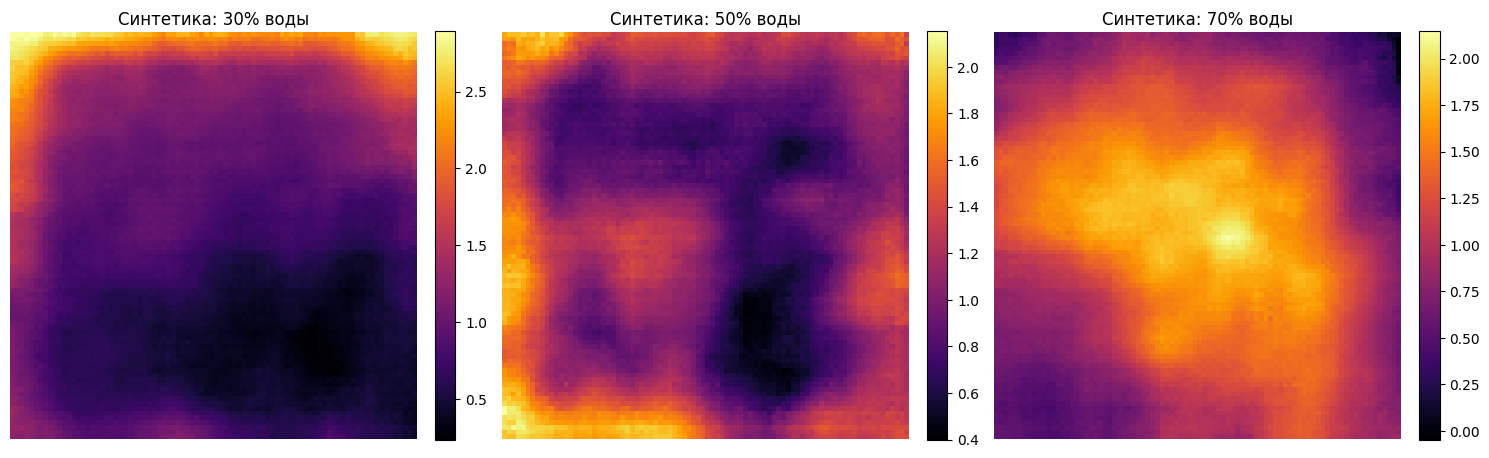

✅ Успех! Сохранено 30 синтетических 2D-кадров в формате .npy.


In [7]:
SYNTHETIC_DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"Экспорт синтетики в: {SYNTHETIC_DATA_DIR.resolve()}")

model.eval()
exported = 0

fig, axs = plt.subplots(1, len(TARGETS_TO_GENERATE), figsize=(15, 5))

with torch.no_grad():
    for i, target_val in enumerate(TARGETS_TO_GENERATE):
        # Вектор условий для генерации (SAMPLES_PER_TARGET штук)
        c_tensor = torch.tensor([[target_val]] * SAMPLES_PER_TARGET, dtype=torch.float32).to(DEVICE)
        
        # Генерируем кадры: на выходе (Batch, 1, 86, 86)
        synth_images = model.generate(c_tensor).cpu().numpy()
        
        # Визуализируем первый сгенерированный кадр для этого таргета
        ax = axs[i]
        im = ax.imshow(synth_images[0, 0], cmap='inferno')
        ax.set_title(f"Синтетика: {int(target_val*100)}% воды")
        ax.axis('off')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
        # Экспорт
        for j in range(SAMPLES_PER_TARGET):
            frame = synth_images[j, 0]
            filename = f"synth_2d_water_{int(target_val*100)}_{j:03d}.npy"
            np.save(SYNTHETIC_DATA_DIR / filename, frame)
            exported += 1

plt.tight_layout()
plt.show()

print(f"✅ Успех! Сохранено {exported} синтетических 2D-кадров в формате .npy.")